# IY021 – SVM vs Catch22+SVM: Dual-Channel (mCherry + GFP) Experimental Time Series

**Goal:** Classify cells by **TF × glucose condition** (6 classes: Nrg1/Rtg1 × 2%/0.1%/0.01% glucose) using both fluorescence channels simultaneously. Features are the mCherry (Msn2) and GFP (Nrg1 or Rtg1) time series concatenated per cell.

Chance level = 1/6 ≈ 16.7%.

**Data:** `EXP-25-IY013/transformed_exp_time_series_data_v2/`

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycatch22
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm import tqdm

sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")

np.random.seed(42)

## 1. Load Data & Assign Labels

In [2]:
# Verify TF mapping per experiment using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_OMID_MAP = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
}
print("TF mapping verification via get_exp_summary")
print("=" * 65)
for prefix, omid in _OMID_MAP.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump = summary_df["pump_contents"].values[0]
    print(f"\n{prefix}  pump={pump}")
    if not tf_df.empty:
        print(tf_df.to_string(index=False))

TF mapping verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORMATION:
• Pro

In [3]:
DATA_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY013/transformed_exp_time_series_data_v2")
META_COLS = ["id", "group", "experiment"]

# Each entry: (mCherry_stem, GFP_stem, label, glucose_pct, TF)
# Label = TF × glucose condition (6 classes)
# Exclusions: 19554 (Mig1/unknown TFs), 19566/group_1344 (ambiguous TF), Cat8 (only 2 of 3 conditions)
FILE_PAIRS = [
    # Nrg1 strain (group 1346)
    ("19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_mCherry_time_series",
     "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_GFP_time_series",
     0, "2%",    "Nrg1"),
    ("19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_mCherry_time_series",
     "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_GFP_time_series",
     1, "0.1%",  "Nrg1"),
    ("20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_mCherry_time_series",
     "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_GFP_time_series",
     2, "0.01%", "Nrg1"),
    # Rtg1 strain (group 1347)
    ("19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_mCherry_time_series",
     "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_GFP_time_series",
     3, "2%",    "Rtg1"),
    ("19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_mCherry_time_series",
     "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_GFP_time_series",
     4, "0.1%",  "Rtg1"),
    ("20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_mCherry_time_series",
     "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_GFP_time_series",
     5, "0.01%", "Rtg1"),
]

label_names = {
    0: "Nrg1 @ 2% glc",    1: "Nrg1 @ 0.1% glc",  2: "Nrg1 @ 0.01% glc",
    3: "Rtg1 @ 2% glc",    4: "Rtg1 @ 0.1% glc",  5: "Rtg1 @ 0.01% glc",
}

# ── Load & merge channels per cell ──────────────────────────────────────────
all_m, all_g, all_y, all_strain = [], [], [], []

for mc_stem, gfp_stem, label, glc, tf in FILE_PAIRS:
    df_m = pd.read_csv(DATA_DIR / f"{mc_stem}.csv")
    df_g = pd.read_csv(DATA_DIR / f"{gfp_stem}.csv")

    tc_m = [c for c in df_m.columns if c not in META_COLS]
    tc_g = [c for c in df_g.columns if c not in META_COLS]

    # Keep only cells present in both channels
    common = set(df_m["id"]) & set(df_g["id"])
    df_m = df_m[df_m["id"].isin(common)].set_index("id").sort_index()
    df_g = df_g[df_g["id"].isin(common)].set_index("id").sort_index()

    all_m.append(df_m[tc_m].values.astype(float))
    all_g.append(df_g[tc_g].values.astype(float))
    all_y.extend([label] * len(common))
    all_strain.extend([tf] * len(common))
    print(f"  {tf} (GFP) / Msn2 (mCherry) @ {glc:>5s} glc  "
          f"— {len(common)} paired cells  "
          f"[mCherry: {len(tc_m)} tp, GFP: {len(tc_g)} tp]")

# Truncate each channel to its own global minimum across all files
min_tp_m = min(a.shape[1] for a in all_m)
min_tp_g = min(a.shape[1] for a in all_g)
print(f"\nTruncating: mCherry → {min_tp_m} tp, GFP → {min_tp_g} tp")

all_m = [a[:, :min_tp_m] for a in all_m]
all_g = [a[:, :min_tp_g] for a in all_g]

# Concatenate channels: [mCherry | GFP]
X_m   = np.vstack(all_m)   # (N, min_tp_m)  — kept separate for plotting
X_g   = np.vstack(all_g)   # (N, min_tp_g)
X_raw = np.concatenate([X_m, X_g], axis=1)   # (N, min_tp_m + min_tp_g)
y       = np.array(all_y,     dtype=int)
strains = np.array(all_strain)

print(f"Dataset: {X_raw.shape[0]} cells × {X_raw.shape[1]} combined timepoints "
      f"({min_tp_m} mCherry + {min_tp_g} GFP)")
for lbl, name in label_names.items():
    print(f"  {lbl}: {name:22s} → {np.sum(y == lbl):4d} cells")

  Nrg1 (GFP) / Msn2 (mCherry) @    2% glc  — 84 paired cells  [mCherry: 128 tp, GFP: 232 tp]
  Nrg1 (GFP) / Msn2 (mCherry) @  0.1% glc  — 231 paired cells  [mCherry: 135 tp, GFP: 219 tp]
  Nrg1 (GFP) / Msn2 (mCherry) @ 0.01% glc  — 231 paired cells  [mCherry: 105 tp, GFP: 104 tp]
  Rtg1 (GFP) / Msn2 (mCherry) @    2% glc  — 78 paired cells  [mCherry: 126 tp, GFP: 146 tp]
  Rtg1 (GFP) / Msn2 (mCherry) @  0.1% glc  — 200 paired cells  [mCherry: 117 tp, GFP: 80 tp]
  Rtg1 (GFP) / Msn2 (mCherry) @ 0.01% glc  — 275 paired cells  [mCherry: 89 tp, GFP: 165 tp]

Truncating: mCherry → 89 tp, GFP → 80 tp
Dataset: 1099 cells × 169 combined timepoints (89 mCherry + 80 GFP)
  0: Nrg1 @ 2% glc          →   84 cells
  1: Nrg1 @ 0.1% glc        →  231 cells
  2: Nrg1 @ 0.01% glc       →  231 cells
  3: Rtg1 @ 2% glc          →   78 cells
  4: Rtg1 @ 0.1% glc        →  200 cells
  5: Rtg1 @ 0.01% glc       →  275 cells


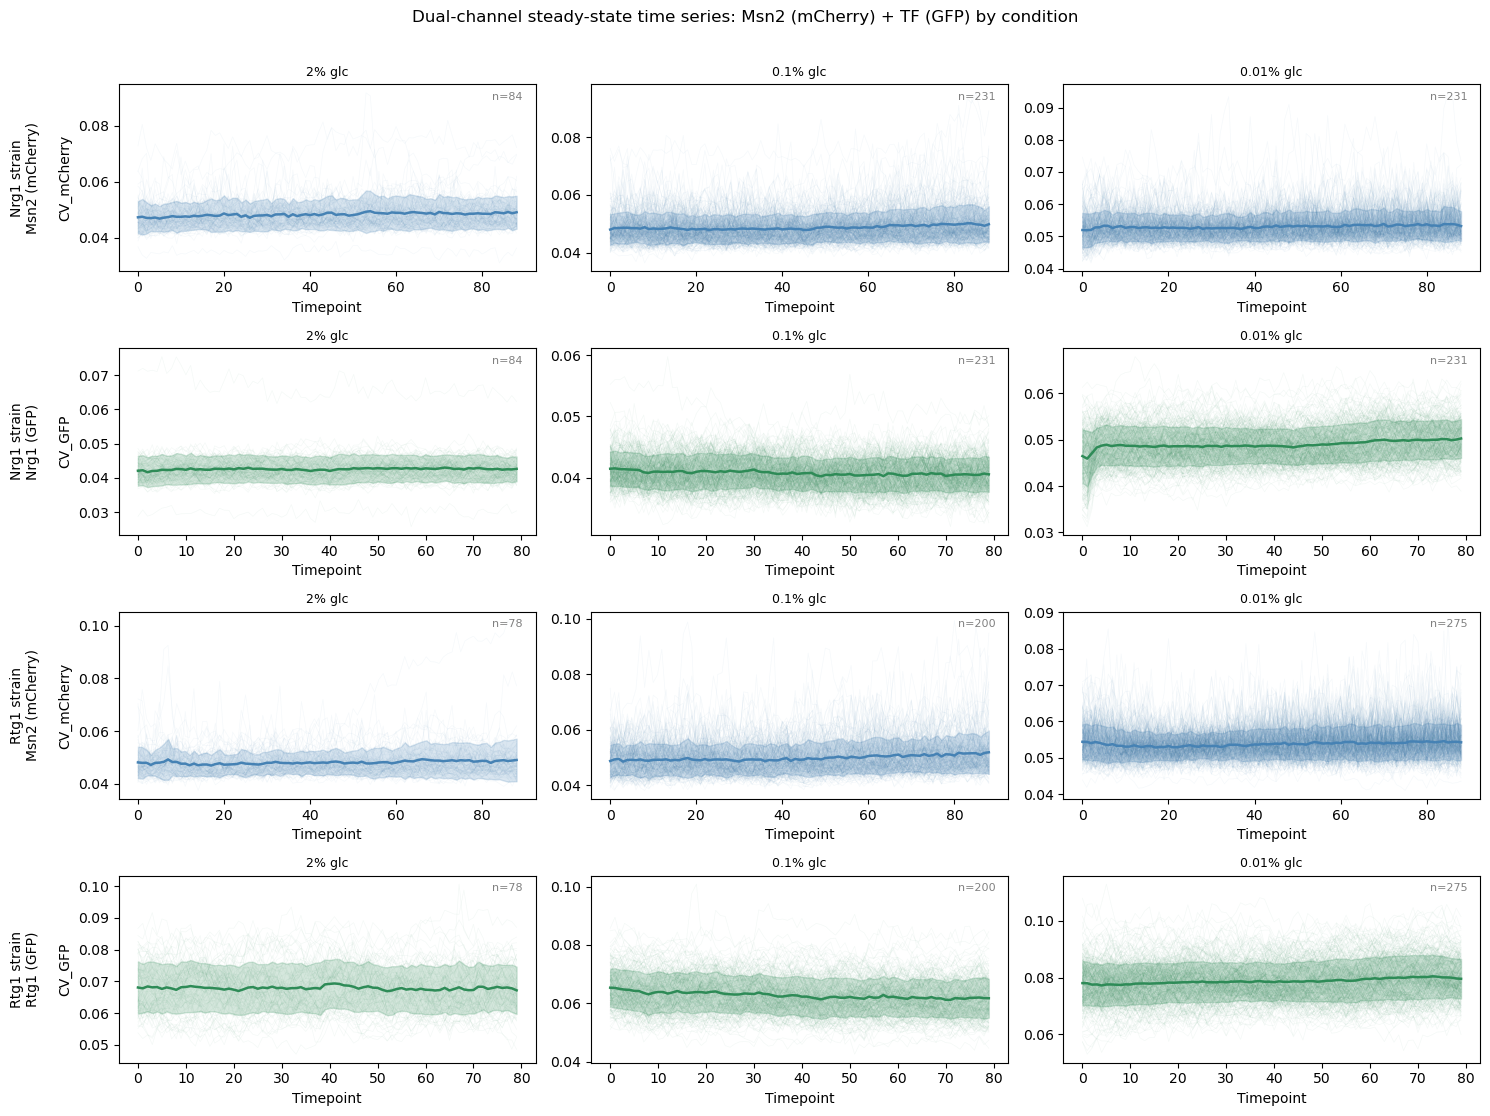

In [4]:
# ── Time series overview: both channels, each TF under each condition ────────
tfs        = ["Nrg1", "Rtg1"]
conditions = [0, 1, 2, 3, 4, 5]   # label order: Nrg1 conditions, then Rtg1

# Map label → condition index for column layout
glc_labels = ["2% glc", "0.1% glc", "0.01% glc"]
t_m = np.arange(min_tp_m)
t_g = np.arange(min_tp_g)

fig, axes = plt.subplots(4, 3, figsize=(15, 11), sharey=False, sharex=False)
# Rows: Nrg1-mCherry, Nrg1-GFP, Rtg1-mCherry, Rtg1-GFP

row_info = [
    ("Nrg1", "mCherry", "Msn2 (mCherry)", "steelblue", [0, 1, 2], t_m, X_m),
    ("Nrg1", "GFP",     "Nrg1 (GFP)",     "seagreen",  [0, 1, 2], t_g, X_g),
    ("Rtg1", "mCherry", "Msn2 (mCherry)", "steelblue", [3, 4, 5], t_m, X_m),
    ("Rtg1", "GFP",     "Rtg1 (GFP)",     "seagreen",  [3, 4, 5], t_g, X_g),
]

for row, (tf, ch, ch_label, color, labels, t_ax, X_ch) in enumerate(row_info):
    for col, (lbl, glc) in enumerate(zip(labels, glc_labels)):
        ax   = axes[row, col]
        mask = y == lbl
        X_sub = X_ch[mask]

        for trace in X_sub:
            ax.plot(t_ax, trace, color=color, alpha=0.05, linewidth=0.5)
        if len(X_sub):
            mean = np.nanmean(X_sub, axis=0)
            std  = np.nanstd(X_sub,  axis=0)
            ax.plot(t_ax, mean, color=color, linewidth=1.8)
            ax.fill_between(t_ax, mean - std, mean + std, color=color, alpha=0.2)

        ax.set_title(f"{glc}", fontsize=9)
        ax.set_xlabel("Timepoint")
        if col == 0:
            ax.set_ylabel(f"{tf} strain\n{ch_label}\n\nCV_{ch}")
        ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color="gray")

fig.suptitle("Dual-channel steady-state time series: Msn2 (mCherry) + TF (GFP) by condition",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 2. Preprocessing: NaN Handling, Balancing & Train/Test Split

In [5]:
def fill_nans(X):
    """Interpolate NaNs per row; fallback to column median."""
    X = X.copy()
    for i in range(X.shape[0]):
        row = pd.Series(X[i])
        row = row.interpolate().ffill().bfill()
        X[i] = row.values
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
    return X

X_clean = fill_nans(X_raw)
print(f"NaN remaining after fill: {np.isnan(X_clean).sum()}")

# Balance classes by subsampling to minority class size
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Minority class count: {min_count} → subsampling all classes to this size")

balanced_idx = []
for lbl in sorted(label_names):
    idx = np.where(y == lbl)[0]
    chosen = np.random.choice(idx, size=min_count, replace=False)
    balanced_idx.extend(chosen)
balanced_idx = np.array(balanced_idx)

X_bal = X_clean[balanced_idx]
y_bal = y[balanced_idx]

print(f"\nBalanced dataset: {X_bal.shape[0]} cells × {X_bal.shape[1]} timepoints")
for lbl, name in label_names.items():
    print(f"  Label {lbl} ({name}): {np.sum(y_bal == lbl)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train class counts: {np.bincount(y_train)}")
print(f"Test  class counts: {np.bincount(y_test)}")

NaN remaining after fill: 0
Minority class count: 78 → subsampling all classes to this size

Balanced dataset: 468 cells × 169 timepoints
  Label 0 (Nrg1 @ 2% glc): 78
  Label 1 (Nrg1 @ 0.1% glc): 78
  Label 2 (Nrg1 @ 0.01% glc): 78
  Label 3 (Rtg1 @ 2% glc): 78
  Label 4 (Rtg1 @ 0.1% glc): 78
  Label 5 (Rtg1 @ 0.01% glc): 78

Train: 374  |  Test: 94
Train class counts: [63 63 62 62 62 62]
Test  class counts: [15 15 16 16 16 16]


## 3. Raw SVM (RBF) – Concatenated Time Series as Features

In [6]:
print("=== Raw SVM (RBF) ===")
class_names = [label_names[i] for i in sorted(label_names)]

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
])
svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"Raw SVM Accuracy: {svm_acc:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=class_names))

=== Raw SVM (RBF) ===
Raw SVM Accuracy: 0.7447

                  precision    recall  f1-score   support

   Nrg1 @ 2% glc       0.56      0.33      0.42        15
 Nrg1 @ 0.1% glc       0.55      0.73      0.63        15
Nrg1 @ 0.01% glc       0.89      1.00      0.94        16
   Rtg1 @ 2% glc       0.68      0.81      0.74        16
 Rtg1 @ 0.1% glc       0.91      0.62      0.74        16
Rtg1 @ 0.01% glc       0.88      0.94      0.91        16

        accuracy                           0.74        94
       macro avg       0.75      0.74      0.73        94
    weighted avg       0.75      0.74      0.73        94



## 4. Catch22 + SVM (RBF)

Catch22 features are extracted from the full concatenated series (mCherry + GFP).

In [7]:
def extract_catch22(X, desc=""):
    """Extract 22 canonical time-series features for each row of X."""
    rows = []
    for ts in tqdm(X, desc=desc, leave=False):
        out = pycatch22.catch22_all(ts.tolist())
        rows.append(dict(zip(out["names"], out["values"])))
    df_feats = pd.DataFrame(rows)
    df_feats = df_feats.replace([np.inf, -np.inf], np.nan)
    df_feats = df_feats.fillna(df_feats.median())
    return df_feats

# Split concatenated series back into individual channels at the known boundary
X_train_m = X_train[:, :min_tp_m]
X_train_g = X_train[:, min_tp_m:]
X_test_m  = X_test[:,  :min_tp_m]
X_test_g  = X_test[:,  min_tp_m:]

print("Extracting Catch22 features — mCherry (train)...")
c22_train_m = extract_catch22(X_train_m, desc="mCherry train")
print("Extracting Catch22 features — GFP (train)...")
c22_train_g = extract_catch22(X_train_g, desc="GFP train")
print("Extracting Catch22 features — mCherry (test)...")
c22_test_m  = extract_catch22(X_test_m,  desc="mCherry test")
print("Extracting Catch22 features — GFP (test)...")
c22_test_g  = extract_catch22(X_test_g,  desc="GFP test")

# Prefix column names to distinguish channels, then concatenate → 44 features
for df in [c22_train_m, c22_test_m]:
    df.columns = [f"mCherry_{c}" for c in df.columns]
for df in [c22_train_g, c22_test_g]:
    df.columns = [f"GFP_{c}" for c in df.columns]

X_train_c22 = pd.concat([c22_train_m.reset_index(drop=True),
                          c22_train_g.reset_index(drop=True)], axis=1)
X_test_c22  = pd.concat([c22_test_m.reset_index(drop=True),
                          c22_test_g.reset_index(drop=True)], axis=1)

print(f"\nCatch22 feature matrix: {X_train_c22.shape[1]} features (22 mCherry + 22 GFP)")

print("\n=== Catch22 + SVM (RBF) ===")
c22_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
])
c22_pipe.fit(X_train_c22, y_train)
y_pred_c22 = c22_pipe.predict(X_test_c22)
c22_acc = accuracy_score(y_test, y_pred_c22)

print(f"Catch22 + SVM Accuracy: {c22_acc:.4f}")
print()
print(classification_report(y_test, y_pred_c22, target_names=class_names))


Extracting Catch22 features — mCherry (train)...


Extracting Catch22 features — GFP (train)...


Extracting Catch22 features — mCherry (test)...


Extracting Catch22 features — GFP (test)...



Catch22 feature matrix: 44 features (22 mCherry + 22 GFP)

=== Catch22 + SVM (RBF) ===
Catch22 + SVM Accuracy: 0.4255

                  precision    recall  f1-score   support

   Nrg1 @ 2% glc       0.41      0.47      0.44        15
 Nrg1 @ 0.1% glc       0.45      0.60      0.51        15
Nrg1 @ 0.01% glc       0.42      0.31      0.36        16
   Rtg1 @ 2% glc       0.50      0.50      0.50        16
 Rtg1 @ 0.1% glc       0.43      0.38      0.40        16
Rtg1 @ 0.01% glc       0.33      0.31      0.32        16

        accuracy                           0.43        94
       macro avg       0.42      0.43      0.42        94
    weighted avg       0.42      0.43      0.42        94



## 5. Results Comparison

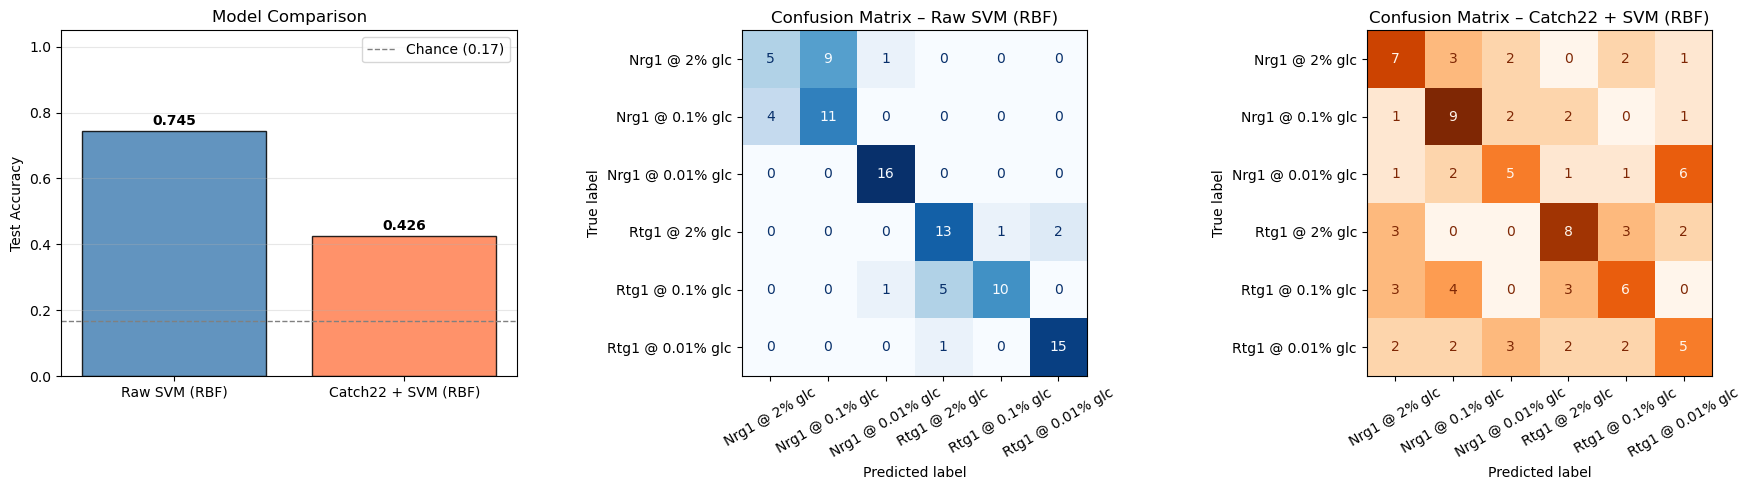


=== Summary ===
  Chance level         : 0.1667
  Raw SVM (RBF)        : 0.7447
  Catch22 + SVM (RBF)  : 0.4255
  Winner: Raw SVM (+0.3191)


In [8]:
class_names = [label_names[i] for i in sorted(label_names)]
chance = 1 / len(label_names)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ["Raw SVM (RBF)", "Catch22 + SVM (RBF)"]
accs   = [svm_acc, c22_acc]
colors = ["steelblue", "coral"]
bars   = axes[0].bar(models, accs, color=colors, alpha=0.85, edgecolor="black")
axes[0].axhline(chance, color="gray", linestyle="--", linewidth=1, label=f"Chance ({chance:.2f})")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Model Comparison")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{acc:.3f}", ha="center", va="bottom", fontweight="bold")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=class_names,
    ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix – Raw SVM (RBF)")
axes[1].tick_params(axis="x", rotation=30)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_c22, display_labels=class_names,
    ax=axes[2], colorbar=False, cmap="Oranges")
axes[2].set_title("Confusion Matrix – Catch22 + SVM (RBF)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("IY021_dual_channel_svm_vs_catch22.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Summary ===")
print(f"  Chance level         : {chance:.4f}")
print(f"  Raw SVM (RBF)        : {svm_acc:.4f}")
print(f"  Catch22 + SVM (RBF)  : {c22_acc:.4f}")
winner = "Raw SVM" if svm_acc >= c22_acc else "Catch22 + SVM"
print(f"  Winner: {winner} (+{abs(svm_acc - c22_acc):.4f})")